In [74]:
import pandas as pd
import os
import re
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import copy

In [75]:
data = pd.read_excel(r'Запчасти списанные в ремонт.xls', skiprows=[0, 1, 2, 3, 4, 5, 6, 7 ,8], dtype=str)
data = data.drop(columns=['Unnamed: 1', 'Unnamed: 5', 'Unnamed: 6'])
data = data.iloc[:-1].reset_index(drop=True)

conditions1 = [
    data['Машина'].str.contains('ножничный', case=False, na=False),
    data['Машина'].str.contains('коленчатый', case=False, na=False),
    data['Машина'].str.contains('телескопический', case=False, na=False),
    data['Машина'].str.contains('мачтовый', case=False, na=False)
]

choices1 = ['ножничный', 'коленчатый', 'телескопический', 'мачтовый']

data['Тип подъемника'] = np.select(conditions1, choices1, default='другое')

conditions2 = [

    data['Машина'].str.contains('электрический', case=False, na=False),
    data['Машина'].str.contains('дизельный', case=False, na=False),
]

choices2 = ['Электрический', 'Дизельный']

data['Тип двигателя'] = np.select(conditions2, choices2, default='другое')

# Убираем строки с Тип подъемника = "другое"
data = data.loc[~(data['Тип подъемника'] == 'другое')]

# Убираем строки, где Машина начинается с "Телескопический погрузчик"
data = data[~(data['Машина'].str.startswith("Телескопический погрузчик"))]

# Присваиваем Тип двигателя для конкретных машин
data.loc[data['Машина'] == 'Телескопический подъемник Zoomlion ZT72J-V', 'Тип двигателя'] = 'Дизельный'
data.loc[data['Машина'] == 'Телескопический подъемник Zoomlion ZT30J', 'Тип двигателя'] = 'Дизельный'

# Преобразуем колонку Дата в datetime и добавляем Квартал
data['Дата'] = pd.to_datetime(data['Дата'], format='%d.%m.%Y %H:%M:%S')
data['Квартал'] = data['Дата'].dt.quarter

# Перемещаем колонку Квартал на третью позицию
col = data.pop("Квартал")  
data.insert(2, "Квартал", col)

df1 = copy.deepcopy(data)
df1.info()
df1.shape[0]

<class 'pandas.DataFrame'>
Index: 9224 entries, 0 to 9347
Data columns (total 20 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Дата                                         9224 non-null   datetime64[us]
 1   Год                                          9224 non-null   str           
 2   Квартал                                      9224 non-null   int32         
 3   Месяц                                        9224 non-null   str           
 4   Номенклатура                                 9224 non-null   str           
 5   Номенклатура.Артикул                         9178 non-null   str           
 6   Номенклатура.Оригинальный номер              8684 non-null   str           
 7   Номенклатура.Оригинальный номер расширенный  5329 non-null   str           
 8   Номенклатура.Тип техники                     9224 non-null   str           
 9   Машина       

9224

In [77]:
df1.head(5)

,Дата,Год,Квартал,Месяц,Номенклатура,Номенклатура.Артикул,Номенклатура.Оригинальный номер,Номенклатура.Оригинальный номер расширенный,Номенклатура.Тип техники,Машина,Машина.Бренд,Машина.Модель техники,Машина.Серия техники,Лот.CRM год выпуска,Серийный номер,Лот.CRM наработка,Документ.Склад,Количество,Тип подъемника,Тип двигателя
0,2023-01-23 15:18:35,2023,1,1,Обогреватель предпусковой БИНАР-5S (дизель) 12 в,НФ-00000397,NaN,NaN,ЗЧ ПО,Подъёмник телескопический дизельный Zoomlion Z...,Zoomlion,ZT26J,ZT,2022,0771400001N000205,NaN,ПТО СК запчасти для арендного парка,1,телескопический,Дизельный
1,2023-01-23 15:18:35,2023,1,1,Гибкая нагревающая пластина 400 Вт 24 В (152х2...,400-24-0-0-3M-15,NaN,NaN,ЗЧ ПО,Подъёмник телескопический дизельный Zoomlion Z...,Zoomlion,ZT26J,ZT,2022,0771400001N000205,NaN,ПТО СК запчасти для арендного парка,4,телескопический,Дизельный
2,2023-01-23 21:14:12,2023,1,1,Разъем НПУ в сборе с проводом Zoomlion,Я0378323,12.02.000009,12.02.000009 Z12.02.000009,ЗЧ ZOOMLION,Подъемник ножничный электрический Sinoboom GTJ...,Sinoboom,0808N,GTJZ,2020,101402926,NaN,ПТО СК запчасти для арендного парка,1,ножничный,Электрический
3,2023-01-23 21:14:12,2023,1,1,Разъем ВПУ (папа),Я0378316,NaN,NaN,ЗЧ ZOOMLION,Подъемник ножничный электрический Sinoboom GTJ...,Sinoboom,0808N,GTJZ,2020,101402926,NaN,ПТО СК запчасти для арендного парка,1,ножничный,Электрический
4,2023-01-24 11:16:25,2023,1,1,Гибкая нагревающая пластина 400 Вт 24 В (152х2...,400-24-0-0-3M-15,NaN,NaN,ЗЧ ПО,Подъёмник телескопический дизельный Zoomlion Z...,Zoomlion,ZT26J,ZT,2022,0771400001N000177,NaN,ПТО СК запчасти для арендного парка,4,телескопический,Дизельный


In [78]:
df2 = pd.read_excel('Остатки и обороты.xls', skiprows=[0, 1, 2, 3, 4, 5, 6, 7], dtype=str)
df2

,Unnamed: 0,Номенклатура,Артикул,Оригинальный номер,Тип техники,Склад,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,2023 г.,NaN,NaN,NaN,NaN,380,4912.68,3454.68,1838
1,NaN,1 квартал 2023 г.,NaN,NaN,NaN,NaN,380,809,537,652
2,NaN,Январь 2023 г.,NaN,NaN,NaN,NaN,380,203,94,489
3,NaN,"Нагреватель ленточный 12В, 1м ЭЛАН 12-1-30-180...",ЭЛАН 12-1-30-180 ПРО,NaN,ЗЧ ПО,БТС Склад запчастей,6,NaN,1,5
4,NaN,"Нагреватель ленточный 12В, 1м ЭЛАН 12-1-30-180...",ЭЛАН 12-1-30-180 ПРО,NaN,ЗЧ ПО,БТС Склад запчастей,7,NaN,1,6
...,...,...,...,...,...,...,...,...,...,...
46101,NaN,Потенциометр 1020520995,1020520995,1020520995,ЗЧ ZOOMLION,Новосибирск. Склад запчастей,1,NaN,NaN,1
46102,NaN,Потенциометр 1020520995,1020520995,1020520995,ЗЧ ZOOMLION,БТС Склад запчастей,4,NaN,NaN,4
46103,NaN,Потенциометр 1020520995,1020520995,1020520995,ЗЧ ZOOMLION,Ростов-на-Дону. Склад запчастей,2,NaN,NaN,2
46104,NaN,Фильтр топливный 29560GT,978434,29560GT,ЗЧ LGMG,Запчасти. Талдом,4,NaN,NaN,4


In [62]:
df1

,Дата,Год,Квартал,Месяц,Номенклатура,Номенклатура.Артикул,Номенклатура.Оригинальный номер,Номенклатура.Оригинальный номер расширенный,Машина,Машина.Бренд,Машина.Модель техники,Машина.Серия техники,Лот.CRM год выпуска,Серийный номер,Лот.CRM наработка,Документ.Склад,Количество,Тип подъемника,Тип двигателя
0,2023-01-23 15:18:35,2023,1,1,Обогреватель предпусковой БИНАР-5S (дизель) 12 в,НФ-00000397,NaN,NaN,Подъёмник телескопический дизельный Zoomlion Z...,Zoomlion,ZT26J,ZT,2022,0771400001N000205,NaN,ПТО СК запчасти для арендного парка,1,телескопический,Дизельный
1,2023-01-23 15:18:35,2023,1,1,Гибкая нагревающая пластина 400 Вт 24 В (152х2...,400-24-0-0-3M-15,NaN,NaN,Подъёмник телескопический дизельный Zoomlion Z...,Zoomlion,ZT26J,ZT,2022,0771400001N000205,NaN,ПТО СК запчасти для арендного парка,4,телескопический,Дизельный
2,2023-01-23 21:14:12,2023,1,1,Разъем НПУ в сборе с проводом Zoomlion,Я0378323,12.02.000009,12.02.000009 Z12.02.000009,Подъемник ножничный электрический Sinoboom GTJ...,Sinoboom,0808N,GTJZ,2020,101402926,NaN,ПТО СК запчасти для арендного парка,1,ножничный,Электрический
3,2023-01-23 21:14:12,2023,1,1,Разъем ВПУ (папа),Я0378316,NaN,NaN,Подъемник ножничный электрический Sinoboom GTJ...,Sinoboom,0808N,GTJZ,2020,101402926,NaN,ПТО СК запчасти для арендного парка,1,ножничный,Электрический
4,2023-01-24 11:16:25,2023,1,1,Гибкая нагревающая пластина 400 Вт 24 В (152х2...,400-24-0-0-3M-15,NaN,NaN,Подъёмник телескопический дизельный Zoomlion Z...,Zoomlion,ZT26J,ZT,2022,0771400001N000177,NaN,ПТО СК запчасти для арендного парка,4,телескопический,Дизельный
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9334,2026-03-06 14:54:19,2026,1,3,Замок зажигания с ключом 84830 ZOOMLION,84830,26.01.000024,1020521389 IHP-30 Y26.01.000024,Подъемник коленчатый дизельный Zoomlion ZA24J,Zoomlion,ZA24J,ZA,2022,2561900100N000086,2276,ПТО СК запчасти для арендного парка,1,коленчатый,Дизельный
9335,2026-03-06 14:55:33,2026,1,3,Кнопка Стоп 122514GT,122514GT,26.01.000002,26.01.000002 Y26.01.000002,Подъемник ножничный электрический Aurora AS080...,Aurora,AS0808,AS,2025,40008JA2473,43,ПТО СК запчасти для арендного парка,1,ножничный,Электрический
9336,2026-03-06 15:06:09,2026,1,3,Фильтр топливный Weichai 1000002416,1000002416,1009806734,NaN,Подъемник коленчатый дизельный Zoomlion ZA14J,Zoomlion,ZA14J,ZA,2024,0773409996R030478,300,Крым. Склад Сервисного обслуживания,1,коленчатый,Дизельный
9337,2026-03-06 15:06:09,2026,1,3,Фильтр масляный ST10070,ST10070,1001740614,NaN,Подъемник коленчатый дизельный Zoomlion ZA14J,Zoomlion,ZA14J,ZA,2024,0773409996R030478,300,Крым. Склад Сервисного обслуживания,2,коленчатый,Дизельный


In [44]:
# Фильтра
filters = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(фильтр|комплект фильтров|элемент фильтра)',
        regex=True,
        na=False
    )
]

filters.to_excel('Фильра.xlsx', index=False)

# Замки
locks = df[
    df['Номенклатура'].str.contains('замок', case=False, na=False)
]

locks.to_excel('Замки.xlsx', index=False)

# Кнопки
buttons = df[
    df['Номенклатура'].str.contains('кнопка', case=False, na=False)
]

buttons.to_excel('Кнопки.xlsx', index=False)

# Батареи
bat = df[
    df['Номенклатура'].str.contains('батарея', case=False, na=False)
]

bat.to_excel('Батареи.xlsx', index=False)

# Обогреватели
heater = df[
    df['Номенклатура'].str.contains('|'.join(['обогреватель', 'нагреватель', 'подогреватель']), case=False, na=False)
]

heater.to_excel('Обогреватели.xlsx', index=False)

# Разъемы
socket = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(разъем)',
        regex=True,
        na=False
    )
]

socket.to_excel('Разъемы.xlsx', index=False)

# Пластины
plate = df[
    df['Номенклатура'].str.contains('пластина', case=False, na=False)
]

plate.to_excel('Пластины.xlsx', index=False)

# Масла
oil = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(масло)',
        regex=True,
        na=False
    )
]

oil.to_excel('Масла.xlsx', index=False)

# Ключи
key = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(ключ)',
        regex=True,
        na=False
    )
]

key.to_excel('Ключи.xlsx', index=False)

# Джойстики
mask_include = df['Номенклатура'].str.contains('|'.join(['джойстик', 'электроджойстик']), case=False, na=False)
mask_exclude = ~df['Номенклатура'].str.contains('рукоятка', case=False, na=False)

joystick = df[mask_include & mask_exclude]

joystick.to_excel('Джойстики.xlsx', index=False)

# Рукава
sleeve = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(рукав)',
        regex=True,
        na=False
    )
]

sleeve.to_excel('Рукава.xlsx', index=False)

# Кабели
cables = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(кабель)',
        regex=True,
        na=False
    )
]

cables.to_excel('Кабеля.xlsx', index=False)

# Тройники
splitter = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(тройник)',
        regex=True,
        na=False
    )
]

splitter.to_excel('Тройники.xlsx', index=False)

# Штуцера
fitting = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(штуцер)',
        regex=True,
        na=False
    )
]

fitting.to_excel('Штуцера.xlsx', index=False)

# ЗУ
charger = df[
    df['Номенклатура'].str.contains('|'.join(['зу', 'устройство зарядное', 'Устройство зарядное', 'Зарядное устройство', 'зарядное устройство']), case=False, na=False)
]
charger = charger[charger['Номенклатура'] != 'ЗУБР МЕХАНИК, размер L, перчатки маслобензостойкие тонкие 11276-L_z01']

charger.to_excel('ЗУ.xlsx', index=False)

# Клапаны
valve = df[
    df['Номенклатура'].str.contains('|'.join(['клапан']), case=False, na=False)
]
lst = [
    'Блок клапанов 92049371A',
    'Прокладка клапанной крышки 713115700',
    'Гидроцилиндр поворота люльки ZA20 (х8) 1010201471 без блока клапанов',
    'Соленоид электромагнитного клапана поворота колёс 92047788'
]
valve = valve[~valve['Номенклатура'].isin(lst)]
valve.to_excel('Клапана.xlsx', index=False)

# Наклейки
stickers = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(наклейка)',
        regex=True,
        na=False
    )
]
stickers.to_excel('Наклейки.xlsx', index=False)

# Тройники
splitter = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(тройник)',
        regex=True,
        na=False
    )
]

splitter.to_excel('Тройники.xlsx', index=False)

# Маячки
beacons = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(маячок)',
        regex=True,
        na=False
    )
]
beacons.to_excel('Маячки.xlsx', index=False)

# Датчики
sensors = df[
    df['Номенклатура'].str.contains('|'.join(['датчик']), case=False, na=False)
]
lst = ['Кронштейн датчика угла 93300721', 'Контакт датчика поворота колеса BA36-44 93300156A',
       'Скоба датчика BA36,BA44 50011001A', 'Контакт датчика поворота колеса BA36-44 93300156A'
]
sensors = sensors[~sensors['Номенклатура'].isin(lst)]
sensors.to_excel('Датчики.xlsx', index=False)

# Чехлы
cover = df[
    df['Номенклатура'].str.contains('|'.join(['чехол', 'термочехол']), case=False, na=False)
]
cover.to_excel('Чехлы.xlsx', index=False)

# Жгуты
harness = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(жгут)',
        regex=True,
        na=False
    )
]
harness.to_excel('Жгуты.xlsx', index=False)

# Пальцы
fingers = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(палец)',
        regex=True,
        na=False
    )
]
fingers.to_excel('Пальцы.xlsx', index=False)

df['Номенклатура'].value_counts()[:20]

C:\Users\a.vorona\AppData\Local\Temp\ipykernel_15408\2344652225.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\a.vorona\AppData\Local\Temp\ipykernel_15408\2344652225.py:48: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\a.vorona\AppData\Local\Temp\ipykernel_15408\2344652225.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\a.vorona\AppData\Local\Temp\ipykernel_15408\2344652225.py:83: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\a.vorona\AppData\Local\Temp\ipykernel_15408\2344652225.py:105: UserWarning: This pattern is interpreted as a

Номенклатура
Фильтр топливный DIFA 6113                                              409
Фильтр топливный SFC62030                                               403
Кнопка Стоп 122514GT                                                    281
Замок зажигания с ключом 84830 ZOOMLION                                 278
Фильтр воздушный внешний DIFA 43121 + внутренний DIFA 43121-01          263
Фильтр масляный C-1141                                                  253
Замок зажигания с ключом 84830/90173  4130000723001 LGMG                246
Фильтр воздушный DIFA 43121                                             245
Фильтр воздушный DIFA 43121-01                                          240
Замок зажигания с ключом IHP-30 (1020520943) 1020521389 ZOOMLION        222
Фильтр топливный ST20754C                                               151
Фильтр масляный LS32929                                                 149
Разъем НПУ в сборе с проводом Zoomlion                                  131

In [45]:
filters_list = set(filters['Номенклатура'])
sensors_list = set(sensors['Номенклатура'])
fingers_list = set(fingers['Номенклатура'])
harness_list = set(harness['Номенклатура'])
cover_list = set(cover['Номенклатура'])
beacons_list = set(beacons['Номенклатура'])
splitter_list = set(splitter['Номенклатура'])
stickers_list = set(stickers['Номенклатура'])
valve_list = set(valve['Номенклатура'])
charger_list = set(charger['Номенклатура'])
fitting_list = set(fitting['Номенклатура'])
cables_list = set(cables['Номенклатура'])
sleeve_list = set(sleeve['Номенклатура'])
joystick_list = set(joystick['Номенклатура'])
key_list = set(key['Номенклатура'])
oil_list = set(oil['Номенклатура'])
plate_list = set(plate['Номенклатура'])
socket_list = set(socket['Номенклатура'])
heater_list = set(heater['Номенклатура'])
bat_list = set(bat['Номенклатура'])
buttons_list = set(buttons['Номенклатура'])
locks_list = set(locks['Номенклатура'])

In [46]:
df['Категория'] = 'другое'

df.loc[df['Номенклатура'].isin(filters_list), 'Категория'] = 'фильтр'
df.loc[df['Номенклатура'].isin(sensors_list), 'Категория'] = 'датчик'
df.loc[df['Номенклатура'].isin(fingers_list), 'Категория'] = 'палец'
df.loc[df['Номенклатура'].isin(harness_list), 'Категория'] = 'жгут'
df.loc[df['Номенклатура'].isin(cover_list), 'Категория'] = 'чехол'
df.loc[df['Номенклатура'].isin(beacons_list), 'Категория'] = 'маячок'
df.loc[df['Номенклатура'].isin(splitter_list), 'Категория'] = 'тройник'
df.loc[df['Номенклатура'].isin(stickers_list), 'Категория'] = 'наклейка'
df.loc[df['Номенклатура'].isin(valve_list), 'Категория'] = 'клапан'
df.loc[df['Номенклатура'].isin(charger_list), 'Категория'] = 'зу'
df.loc[df['Номенклатура'].isin(fitting_list), 'Категория'] = 'штуцер'
df.loc[df['Номенклатура'].isin(cables_list), 'Категория'] = 'кабель'
df.loc[df['Номенклатура'].isin(sleeve_list), 'Категория'] = 'рукав'
df.loc[df['Номенклатура'].isin(joystick_list), 'Категория'] = 'джойстик'
df.loc[df['Номенклатура'].isin(key_list), 'Категория'] = 'ключ'
df.loc[df['Номенклатура'].isin(oil_list), 'Категория'] = 'масло'
df.loc[df['Номенклатура'].isin(plate_list), 'Категория'] = 'пластина'
df.loc[df['Номенклатура'].isin(socket_list), 'Категория'] = 'разъем'
df.loc[df['Номенклатура'].isin(heater_list), 'Категория'] = 'обогреватель'
df.loc[df['Номенклатура'].isin(bat_list), 'Категория'] = 'батарея'
df.loc[df['Номенклатура'].isin(buttons_list), 'Категория'] = 'кнопка'
df.loc[df['Номенклатура'].isin(locks_list), 'Категория'] = 'замок'

In [47]:
def merge_numbers(row):
    orig = str(row['Номенклатура.Оригинальный номер'])
    ext = str(row['Номенклатура.Оригинальный номер расширенный'])
    # разбиваем по любому количеству пробелов
    ext_list = ext.split()
    if orig in ext_list:
        return ext  # уже есть — не добавляем
    else:
        return ext + ' ' + orig  # добавляем через пробел

filters['Аналоги'] = filters[filters['Номенклатура.Оригинальный номер расширенный'].notna()].apply(merge_numbers, axis=1)

In [48]:
filters

,Дата,Квартал,Год,Месяц,Номенклатура,Номенклатура.Артикул,Номенклатура.Оригинальный номер,Номенклатура.Оригинальный номер расширенный,Машина,Машина.Бренд,Машина.Модель техники,Машина.Серия техники,Лот.CRM год выпуска,Серийный номер,Лот.CRM наработка,Документ.Склад,Количество,Тип подъемника,Тип двигателя,Аналоги
567,2024-06-28 00:00:00,2,2024,6,Фильтр воздушный AP30436,AP30436,1G65911222,P822686 1G65911222,Подъемник ножничный дизельный LGMG SR1218D,LGMG,SR1218D,SR,2022,LWJAS120HM0720034,1648,С-Петербург. Ремзона аренды,1,ножничный,Дизельный,P822686 1G65911222
568,2024-06-28 00:00:00,2,2024,6,Фильтр воздушный AP30436,AP30436,1G65911222,P822686 1G65911222,Подъемник ножничный дизельный LGMG SR1218D,LGMG,SR1218D,SR,2022,LWJAS120VM0720028,1549,С-Петербург. Ремзона аренды,1,ножничный,Дизельный,P822686 1G65911222
577,2024-06-28 00:00:00,2,2024,6,Фильтр топливный FK29021K,FK29021K,26560017,706497 ST20117,Подъемник коленчатый дизельный Dingli BA22CRT,Dingli,BA22CRT,BA,2023,BARC023G00019,2374,С-Петербург. Ремзона аренды,1,коленчатый,Дизельный,706497 ST20117 26560017
609,2024-07-11 10:57:03,3,2024,7,Фильтр воздушный DIFA 43121-01,43121-01,90031459,90031459 P600975 Z32603,Подъемник коленчатый дизельный Dingli BA28RT,Dingli,BA28RT,BA,2023,BAR2800023G0428,2649,С-Петербург. Склад Запчасти,1,коленчатый,Дизельный,90031459 P600975 Z32603
616,2024-07-11 17:58:21,3,2024,7,Фильтр воздушный DIFA 43121-01,43121-01,90031459,90031459 P600975 Z32603,Подъемник коленчатый дизельный Dingli BA28RT,Dingli,BA28RT,BA,2024,BARM023J00072,2875,С-Петербург. Склад Запчасти,1,коленчатый,Дизельный,90031459 P600975 Z32603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9331,2026-03-06 14:50:12,1,2026,3,Фильтр топливный грубой очистки FH21660NN,FH21660NN,FH21660NN,FS53060,Подъемник коленчатый дизельный Sinoboom AB26J ...,Sinoboom,AB26J Plus,AB,2024,402900294,10,ПТО СК запчасти для арендного парка,1,коленчатый,Дизельный,FS53060 FH21660NN
9332,2026-03-06 14:50:51,1,2026,3,Фильтр гидравлический напорный 00004696,4696,4696,NaN,Подъемник коленчатый дизельный Dingli BA44RT,Dingli,BA44RT,BA,2025,BART025D00241,7,ПТО СК запчасти для арендного парка,1,коленчатый,Дизельный,NaN
9333,2026-03-06 14:52:02,1,2026,3,Фильтр топливный грубой очистки FH21660NN,FH21660NN,FH21660NN,FS53060,Подъемник коленчатый дизельный Sinoboom AB26J ...,Sinoboom,AB26J Plus,AB,2024,402900255,6,ПТО СК запчасти для арендного парка,1,коленчатый,Дизельный,FS53060 FH21660NN
9336,2026-03-06 15:06:09,1,2026,3,Фильтр топливный Weichai 1000002416,1000002416,1009806734,NaN,Подъемник коленчатый дизельный Zoomlion ZA14J,Zoomlion,ZA14J,ZA,2024,0773409996R030478,300,Крым. Склад Сервисного обслуживания,1,коленчатый,Дизельный,NaN


In [49]:
(df[df['Категория'] == 'фильтр']
 .groupby(['Год', 'Документ.Склад'])
 .size()
 .unstack())

Документ.Склад,Пенза. Склад Запчастей для Сервиса,Тобольск. Склад Запчастей для Сервиса,Братск ( Усть-Кут). Склад Запчастей для Сервиса,Усть-Луга. Склад Запчастей для Сервиса,БТС Сервисное обслуживание,Барнаул. Сервисное обслуживание,Благовещенск. Сервисное обслуживание,Благовещенск. Склад Запчастей,Благовещенск. Склад Запчастей для Сервиса,Владивосток. Сервисное обслуживание,...,Самара. Склад запчастей,Саратов. Сервисное обслуживание.,Саратов. Склад Запчастей для Сервиса,Спектр. Ростов-на-Дону. Сервисное обслуживание,Тула. Сервисное обслуживание,Уфа. Ремзона,Уфа. Сервисное обслуживание,Череповец Склад Запчастей для Сервиса,Ярославль. Сервисное обслуживание,Ярославль. Склад запчасти
Год,,,,,,,,,,,,,,,,,,,,,
2024,NaN,NaN,5.0,125.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,41.0,NaN,NaN,NaN,NaN,NaN,NaN
2025,7.0,10.0,13.0,1392.0,1.0,NaN,137.0,12.0,14.0,12.0,...,2.0,28.0,39.0,201.0,1.0,10.0,6.0,52.0,NaN,NaN
2026,5.0,16.0,4.0,363.0,NaN,12.0,120.0,NaN,NaN,50.0,...,NaN,42.0,NaN,62.0,5.0,NaN,17.0,24.0,2.0,1.0


In [50]:
import pandas as pd
import networkx as nx

G = nx.Graph()

for idx, row in df.iterrows():
    ext = row['Номенклатура.Оригинальный номер расширенный']
    if pd.isna(ext):  # пропускаем пустые
        continue
    numbers = str(ext).split()  # приводим к строке и разбиваем по пробелу
    # соединяем все номера между собой
    for i in range(len(numbers)):
        for j in range(i+1, len(numbers)):
            G.add_edge(numbers[i], numbers[j])

# связные компоненты = группы аналогов
groups = list(nx.connected_components(G))

# создаём словарь: номер → группа
group_mapping = {}
for i, grp in enumerate(groups):
    for n in grp:
        group_mapping[n] = i

# создаём колонку с номером группы для каждой строки
def assign_group(ext):
    if pd.isna(ext):
        return None
    numbers = str(ext).split()
    # можно взять группу первой позиции
    return group_mapping.get(numbers[0], None)

df['Группа_аналогов'] = df['Номенклатура.Оригинальный номер расширенный'].apply(assign_group)

In [51]:
df.at[255, 'Номенклатура.Оригинальный номер расширенный']

nan

In [52]:
df.loc[df['Группа_аналогов'] == 7, 'Номенклатура'].value_counts()

Номенклатура
Гидронасос 1010001908    2
Name: count, dtype: int64

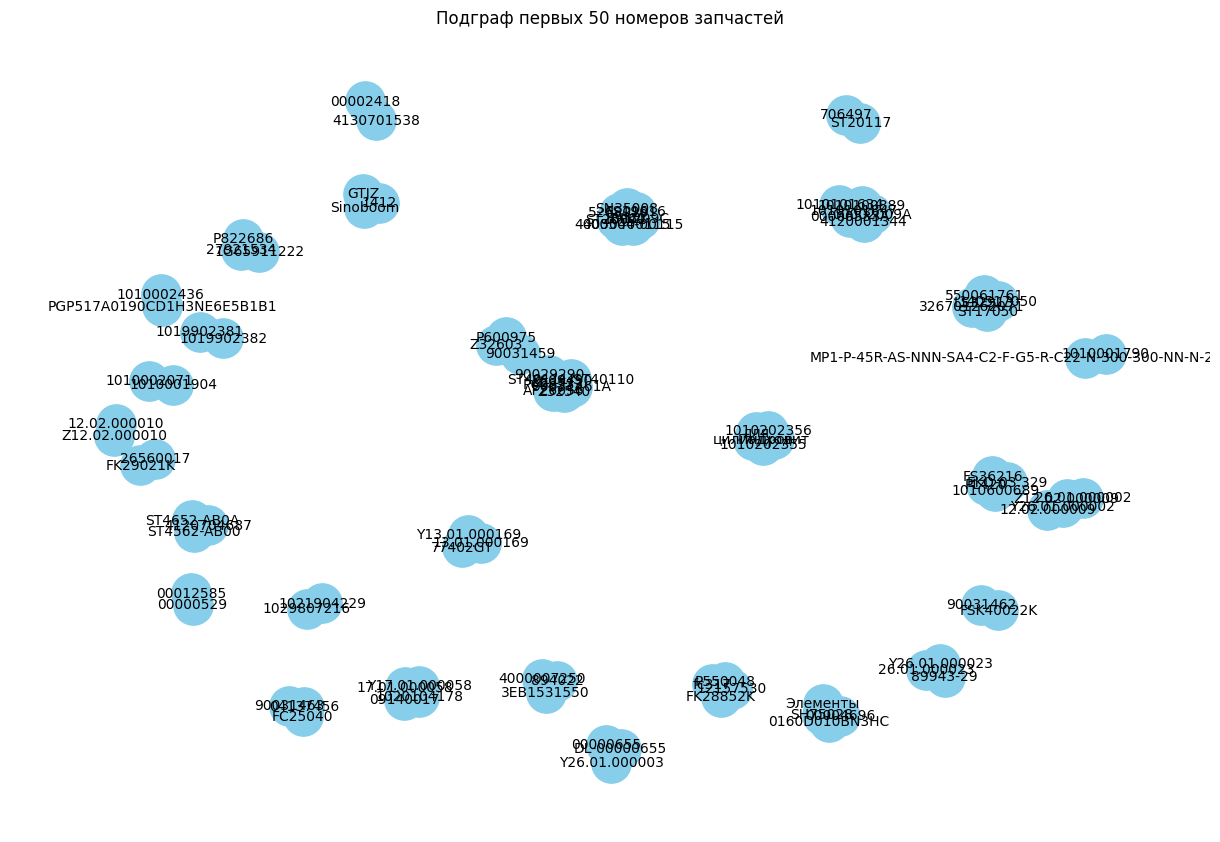

In [53]:
import matplotlib.pyplot as plt
import networkx as nx


sub_nodes = list(G.nodes)[:100]
H = G.subgraph(sub_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(H, seed=42) 
nx.draw(H, pos, with_labels=True, node_color='skyblue', node_size=800, font_size=10, edge_color='gray')
plt.title("Подграф первых 50 номеров запчастей")
plt.show()